<a href="https://colab.research.google.com/github/AkshayaMantipally/cg_DataScience_assignment/blob/main/Task_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**company scenario(FlipKart/amazon):**

we are seeing a drop in revenue find the reason and suggest actions

In [ ]:
#omporting the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the data
customers=pd.read_csv('customers.csv')
orders=pd.read_csv('orders.csv')
products=pd.read_csv('products.csv')

In [ ]:
customers.head()

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20


In [ ]:
orders.head()

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3


In [ ]:
products.head()

,product_id,product_name,category,price
0,201,Laptop,Electronics,70000
1,202,Mobile,Electronics,20000
2,203,Tablet,Electronics,15000
3,204,Shoes,Fashion,3000
4,205,Watch,Fashion,5000


In [ ]:
#joining the tables for ananlysis
df=pd.merge(customers,orders,on='customer_id',how='inner')
df=pd.merge(df,products,on='product_id',how='inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#convertiinto
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])

In [ ]:
#converting revenue column
#formula:revenue=price*quantity
df["revenue"]=df["price"]*df["quantity"]
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


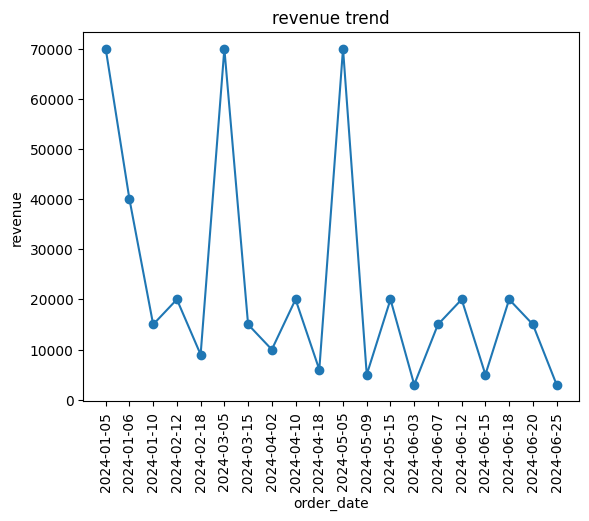

,order_date,revenue
0,2024-01-05,70000
1,2024-01-06,40000
2,2024-01-10,15000
3,2024-02-12,20000
4,2024-02-18,9000


In [ ]:
#revenue trend by order_date
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['order_date'],revenue['revenue'],marker='o')
plt.xlabel('order_date')
plt.ylabel('revenue')
plt.title('revenue trend')
plt.xticks(rotation=90)
plt.show()
revenue.head()

**The revenue is very less in last two months (jun,july)**

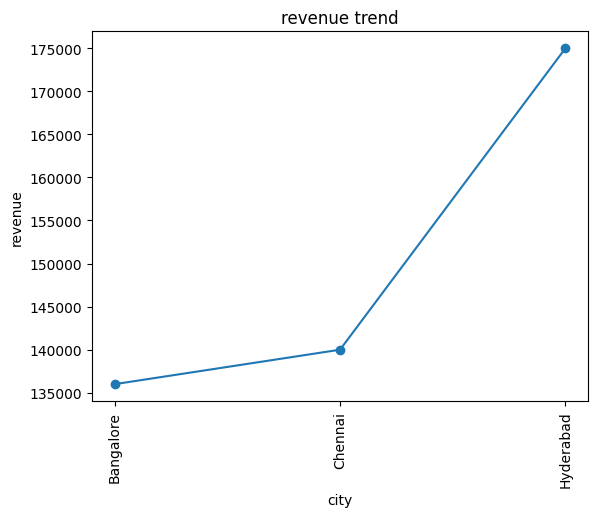

,city,revenue
0,Bangalore,136000
1,Chennai,140000
2,Hyderabad,175000


In [ ]:
#revenue trend by city
revenue=df.groupby("city")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['city'],revenue['revenue'],marker='o')
plt.xlabel('city')
plt.ylabel('revenue')
plt.title('revenue trend')
plt.xticks(rotation=90)
plt.show()
revenue.head()

**revenue is dropping in banglore**

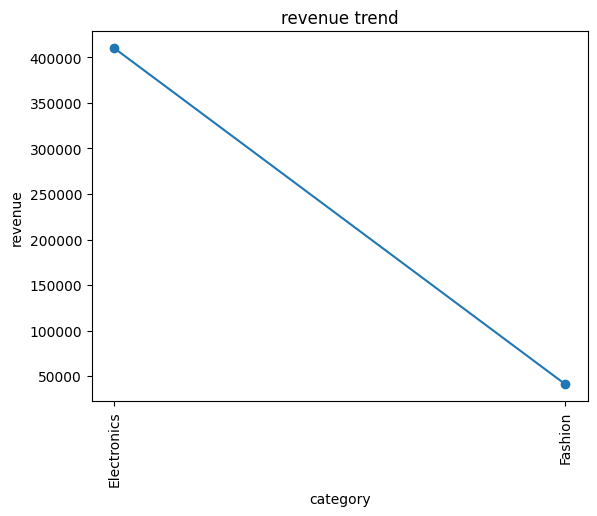

,category,revenue
0,Electronics,410000
1,Fashion,41000


In [ ]:
#revenue trend by category
revenue=df.groupby("category")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['category'],revenue['revenue'],marker='o')
plt.xlabel('category')
plt.ylabel('revenue')
plt.title('revenue trend')
plt.xticks(rotation=90)
plt.show()
revenue.head()

In [ ]:
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


**in fashion category the revenue got dropped**

In [ ]:
#count the no.of customers based on order_id
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**most of the customers are ordering less**

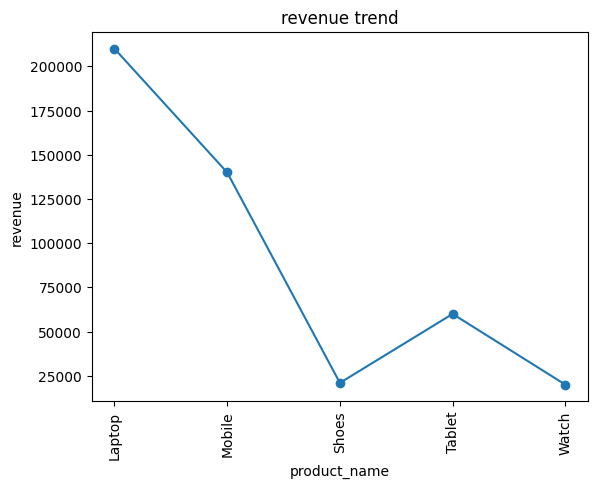

,product_name,revenue
0,Laptop,210000
1,Mobile,140000
2,Shoes,21000
3,Tablet,60000
4,Watch,20000


In [ ]:
#revenue trend by product_name
revenue=df.groupby("product_name")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue['product_name'],revenue['revenue'],marker='o')
plt.xlabel('product_name')
plt.ylabel('revenue')
plt.title('revenue trend')
plt.xticks(rotation=90)
plt.show()
revenue.head()

**revenue is less for shoes and watches**

#Insights:
1)revenue got dropped in the last 2 months(jun,july)

2)Banglore contributed more in revenue drop

3)Fashion Category recorded less revenue

4)repeted customers orderd less

5)shoes and watches declined significantly



#Recommendation:

1)marketing should be done in banglore

2)provide discounts for shoe and watch

3)give coupns,discounts,loyolty programs for the repeated customers


